In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape

c:\Users\Admin HP\OneDrive\Desktop\MyDataScienceProject\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(50000, 32, 32, 3)

In [3]:
X_test.shape

(10000, 32, 32, 3)

Here we see there are 50000 training images and 1000 test images

In [4]:
y_train.shape

(50000, 1)

In [5]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

y_train is a 2D array, for our classification having 1D array is good enough. so we will convert this to now 1D array

In [6]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [7]:
y_test = y_test.reshape(-1,)

In [8]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

Let's plot some images to see what they are 

In [9]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

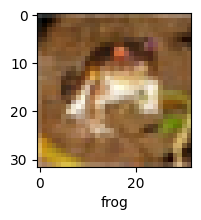

In [10]:
plot_sample(X_train, y_train, 0)

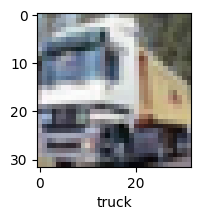

In [11]:
plot_sample(X_train, y_train, 1)

Normalize the images to a number from 0 to 1. Image has 3 channels (R,G,B) and each value in the channel can range from 0 to 255. Hence to normalize in 0-->1 range, we need to divide it by 255

<h4 style="color:purple">Normalizing the training data</h4>

In [12]:
X_train = X_train / 255.0
X_test = X_test / 255.0

<h4 style="color:purple">Build simple artificial neural network for image classification</h4>

In [13]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')    
    ])

c:\Users\Admin HP\OneDrive\Desktop\MyDataScienceProject\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Softmax converts outputs into probabilities.Mostly in the output layer of multi-class classification.

ReLU (Rectified Linear Unit) ->f(x)=max(0,x) ->converts all negative values to 0 and keeps positive values unchanged.

In [15]:
ann.fit(X_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.3530 - loss: 1.8141
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.4267 - loss: 1.6229
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 101s 42ms/step - accuracy: 0.4590 - loss: 1.5415
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.4804 - loss: 1.4796
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 59ms/step - accuracy: 0.4987 - loss: 1.4295


In [16]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy 

In [17]:
y_pred = ann.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


In [18]:
y_pred

array([[0.02380754, 0.03661802, 0.10533204, ..., 0.00627563, 0.0516654 ,
        0.00595857],
       [0.13929422, 0.07466222, 0.00853185, ..., 0.00278271, 0.34567454,
        0.41203326],
       [0.4044889 , 0.04735395, 0.00479987, ..., 0.00681755, 0.4573483 ,
        0.06761248],
       ...,
       [0.00173656, 0.00121007, 0.09702174, ..., 0.03300393, 0.00934016,
        0.00350619],
       [0.03030224, 0.01325796, 0.19815794, ..., 0.04697003, 0.00314537,
        0.01048257],
       [0.07260036, 0.00507708, 0.12892015, ..., 0.4512202 , 0.00955873,
        0.0099069 ]], shape=(10000, 10), dtype=float32)

In [19]:
y_pred_classes = [np.argmax(element) for element in y_pred]

In [20]:
y_pred_classes

[np.int64(3),
 np.int64(9),
 np.int64(8),
 np.int64(0),
 np.int64(4),
 np.int64(6),
 np.int64(3),
 np.int64(4),
 np.int64(4),
 np.int64(1),
 np.int64(8),
 np.int64(9),
 np.int64(6),
 np.int64(7),
 np.int64(9),
 np.int64(8),
 np.int64(7),
 np.int64(7),
 np.int64(8),
 np.int64(6),
 np.int64(4),
 np.int64(0),
 np.int64(0),
 np.int64(9),
 np.int64(4),
 np.int64(6),
 np.int64(6),
 np.int64(0),
 np.int64(9),
 np.int64(6),
 np.int64(6),
 np.int64(4),
 np.int64(4),
 np.int64(5),
 np.int64(9),
 np.int64(1),
 np.int64(6),
 np.int64(9),
 np.int64(9),
 np.int64(5),
 np.int64(0),
 np.int64(6),
 np.int64(9),
 np.int64(6),
 np.int64(0),
 np.int64(9),
 np.int64(3),
 np.int64(8),
 np.int64(4),
 np.int64(6),
 np.int64(9),
 np.int64(4),
 np.int64(6),
 np.int64(3),
 np.int64(8),
 np.int64(8),
 np.int64(5),
 np.int64(6),
 np.int64(6),
 np.int64(2),
 np.int64(7),
 np.int64(3),
 np.int64(1),
 np.int64(9),
 np.int64(6),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(3),
 np.int64(9),
 np.int64(2),
 np.in

In [21]:
print("Classification Report: \n", classification_report(y_test, y_pred_classes))

Classification Report: 
               precision    recall  f1-score   support

           0       0.47      0.65      0.54      1000
           1       0.73      0.41      0.53      1000
           2       0.40      0.31      0.35      1000
           3       0.39      0.24      0.30      1000
           4       0.41      0.41      0.41      1000
           5       0.44      0.33      0.38      1000
           6       0.45      0.69      0.54      1000
           7       0.47      0.64      0.54      1000
           8       0.65      0.60      0.62      1000
           9       0.53      0.58      0.56      1000

    accuracy                           0.49     10000
   macro avg       0.49      0.49      0.48     10000
weighted avg       0.49      0.49      0.48     10000



<h4 style="color:purple">Now let us build a convolutional neural network to train our images</h4>

In [22]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    # CNN applies 32 filters (feature detectors).Each filter size:3 × 3
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # here ann starts
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

c:\Users\Admin HP\OneDrive\Desktop\MyDataScienceProject\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Each filter learns a different pattern.

Example:

Filter 1 → horizontal edges
Filter 2 → vertical edges
Filter 3 → curves
...
Filter 32 → other features

Input Layers->input_shape=(32,32,3),Height = 32 pixels
Width = 32 pixels
Channels = 3 (RGB)

MaxPooling2D((2,2))

Pool size:

2 × 2

Example:

Before:

# 4 8
# 3 6

After pooling:

# 8

(Maximum value selected)

First Max Pooling

Reduces image size

30 × 30 × 32
->
15 × 15 × 32

Second Max Pooling

13 × 13 × 64
->
6 × 6 × 64

Flatten()

Current output:

6 × 6 × 64

CNN converts it into a single vector:

6 × 6 × 64 = 2304 values

Output:

[ x1, x2, x3, ..., x2304 ]

In [23]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Adam is usually the default choice for CNNs because:
Faster convergence

It often reaches good accuracy faster than SGD.

| Situation                         | Output Layer         | Loss Function                     |
| --------------------------------- | -------------------- | --------------------------------- |
| 2 classes                         | `Dense(1, sigmoid)`  | `binary_crossentropy`             |
| Multiple classes + integer labels | `Dense(10, softmax)` | `sparse_categorical_crossentropy` |
| Multiple classes + one-hot labels | `Dense(10, softmax)` | `categorical_crossentropy`        |


In [24]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.4710 - loss: 1.4713
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6118 - loss: 1.1049
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6626 - loss: 0.9683
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6968 - loss: 0.8773
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - accuracy: 0.7198 - loss: 0.8047
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7405 - loss: 0.7482
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 32ms/step - accuracy: 0.7575 - loss: 0.6934
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7731 - loss: 0.6511
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - accuracy: 0.7866 - loss: 0.6097
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8014 - loss: 0.5670


**With CNN, at the end 5 epochs, accuracy was at around 70% which is a significant improvement over ANN. CNN's are best for image classification and gives superb accuracy. Also computation is much less compared to simple ANN as maxpooling reduces the image dimensions while still preserving the features**

In [25]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6825 - loss: 0.9707


[0.9707159399986267, 0.6825000047683716]

In [26]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


array([[2.8471509e-04, 9.0894486e-05, 6.4368255e-04, 8.6429358e-01,
        1.7320794e-04, 1.2972225e-01, 2.3828056e-03, 8.3125102e-05,
        2.3180882e-03, 7.5676417e-06],
       [8.0068968e-03, 1.6669300e-01, 7.6152105e-07, 2.3343605e-06,
        7.5756930e-08, 2.1476714e-07, 1.1440836e-08, 2.2515004e-11,
        8.2527328e-01, 2.3474882e-05],
       [1.0861862e-01, 2.6462317e-01, 1.2515577e-04, 1.5176556e-03,
        5.4236763e-04, 5.8983604e-04, 3.8194576e-05, 4.0466920e-04,
        6.1649126e-01, 7.0490302e-03],
       [9.3029433e-01, 9.2623715e-04, 5.5777640e-03, 3.3375428e-03,
        3.7153899e-03, 3.3211862e-04, 7.4423244e-04, 2.3647430e-05,
        5.4535944e-02, 5.1293819e-04],
       [6.3761013e-06, 2.4513385e-04, 3.9484259e-02, 9.8428167e-03,
        5.8913463e-01, 7.1443017e-03, 3.5413414e-01, 3.3528357e-07,
        7.4975092e-06, 4.2670885e-07]], dtype=float32)

In [27]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(4)]

In [28]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

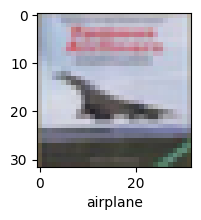

In [29]:
plot_sample(X_test, y_test,3)

In [30]:
classes[y_classes[3]]

'airplane'